In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset from sklearn
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# Check dataset shape (rows, columns)
print("Shape:", df.shape)

# Check data types and missing values
df.info()

# Check for null values explicitly
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Descriptive statistics for features
df.describe()

Shape: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB

Missing Values per Column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


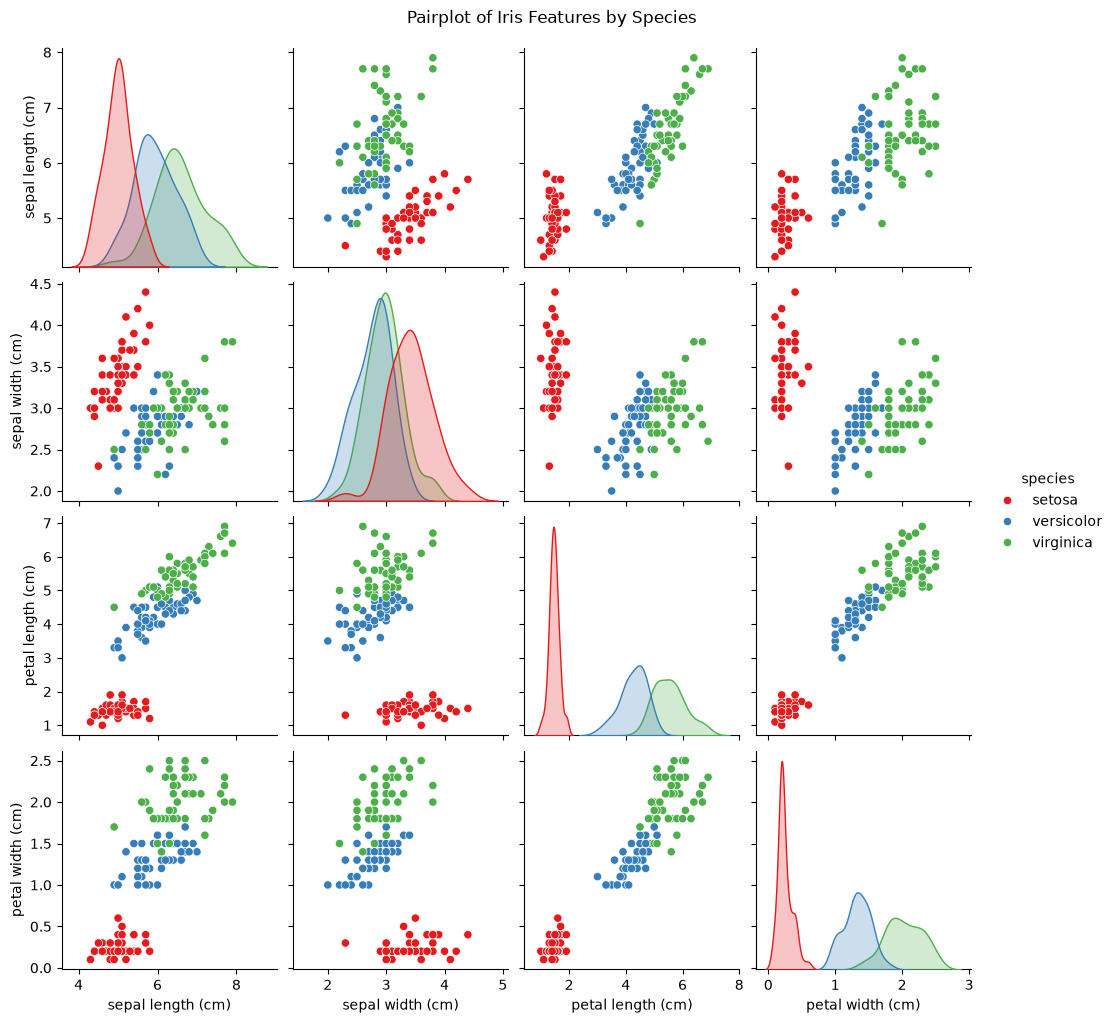

C:\Users\Shrusti S\AppData\Local\Temp\ipykernel_3872\1726388012.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i//2, i%2], palette='Set2')
C:\Users\Shrusti S\AppData\Local\Temp\ipykernel_3872\1726388012.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i//2, i%2], palette='Set2')
C:\Users\Shrusti S\AppData\Local\Temp\ipykernel_3872\1726388012.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i//2, i%2], palette='Set2')
C

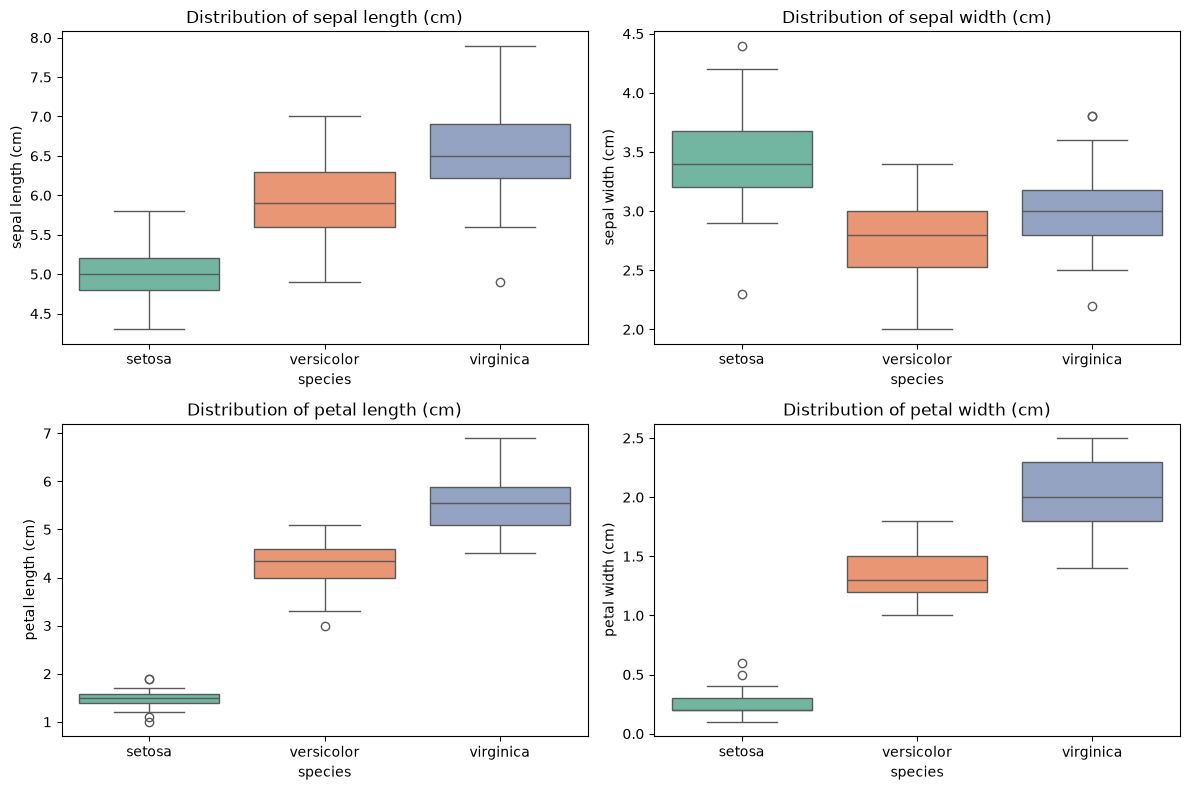

In [3]:
# 1. Pairplot (Scatter matrix colored by species)
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

# 2. Box plots for each numeric feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for i, col in enumerate(features):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i//2, i%2], palette='Set2')
    axes[i//2, i%2].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [4]:
# Separate features and target
X = iris.data
y = iris.target

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 120
Testing set size: 30


In [5]:
# Define dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy score
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    # Print evaluation metrics
    print(f"=== {name} ===")
    print(f"Accuracy: {acc * 100:.2f}%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
    print("-" * 50)

=== Logistic Regression ===
Accuracy: 96.67%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

--------------------------------------------------
=== K-Nearest Neighbors ===
Accuracy: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00  

In [6]:
# Summary Table
summary_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
summary_df['Accuracy (%)'] = summary_df['Accuracy'] * 100
print(summary_df.sort_values(by='Accuracy', ascending=False).to_string(index=False))

              Model  Accuracy  Accuracy (%)
K-Nearest Neighbors  1.000000    100.000000
Logistic Regression  0.966667     96.666667
      Decision Tree  0.933333     93.333333
      Random Forest  0.900000     90.000000
